In [ ]:
 !pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import ultralytics

print(ultralytics.__version__)

8.4.118


In [ ]:
!pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="8xAF3ECJP6LFW6K7s6Nf")
project = rf.workspace("capstone-nh0nc").project("car-damage-detection-t0g92")
dataset = project.version(1).download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Car-Damage-Detection-1 in yolov8:: 100%|██████████| 8110/8110 [00:00<00:00, 12389.93it/s]


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'Car-Damage-Detection-1', 'sample_data']


In [ ]:
dataset_path = "/content/Car-Damage-Detection-1"

print(os.listdir(dataset_path))

['data.yaml', 'README.roboflow.txt', 'valid', 'train', 'test', 'README.dataset.txt']


In [ ]:
!cat /content/Car-Damage-Detection-1/data.yaml

names:
- Bonnet
- Bumper
- Dickey
- Door
- Fender
- Light
- Windshield
nc: 7
roboflow:
  license: CC BY 4.0
  project: car-damage-detection-t0g92
  url: https://universe.roboflow.com/capstone-nh0nc/car-damage-detection-t0g92/dataset/1
  version: 1
  workspace: capstone-nh0nc
test: ../test/images
train: ../train/images
val: ../valid/images


Number of training images: 3567


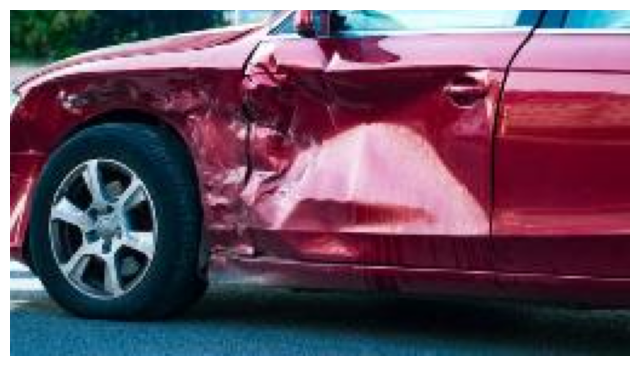

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_images = os.listdir(
    "/content/Car-Damage-Detection-1/train/images"
)

print("Number of training images:", len(train_images))

img_path = "/content/Car-Damage-Detection-1/train/images/" + train_images[1]

img = Image.open(img_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
train_labels = os.listdir(
    "/content/Car-Damage-Detection-1/train/labels"
)

print("Number of label files:", len(train_labels))

Number of label files: 3567


Class Distribution:
Door         : 861
Light        : 2065
Bonnet       : 354
Bumper       : 1011
Dickey       : 1374
Fender       : 1014
Windshield   : 417


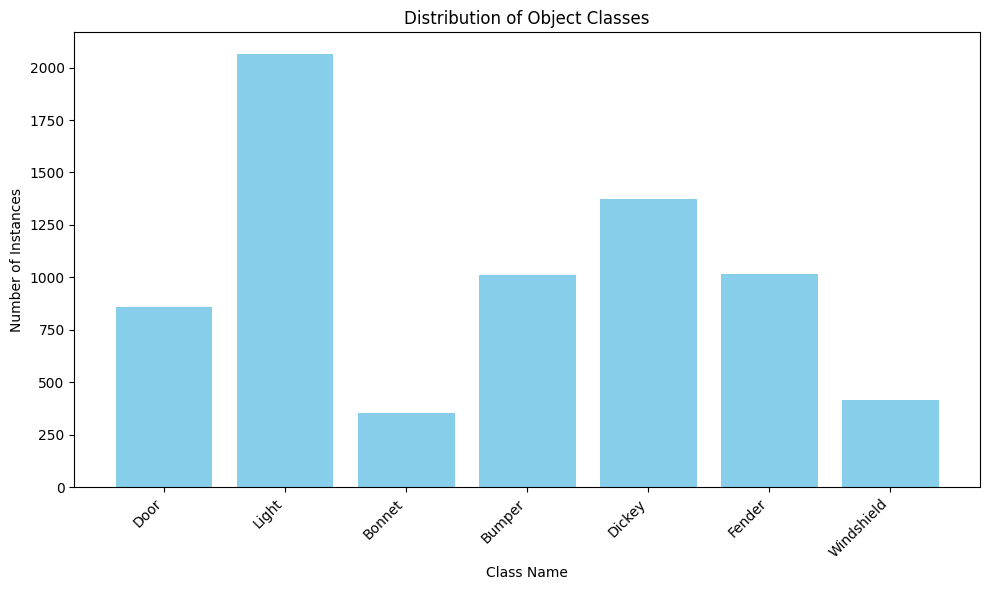

In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt

# Define label_path at the beginning of the cell
label_path = "/content/Car-Damage-Detection-1/train/labels"

class_names = [
    "Door",
    "Light",
    "Bonnet",
    "Bumper",
    "Dickey",
    "Fender",
    "Windshield"
]

class_count = Counter()

for file in os.listdir(label_path):

    if file.endswith(".txt"):

        with open(os.path.join(label_path, file), "r") as f:

            for line in f:
                line = line.strip()

                if line:
                    # Convert to float first, then to int to handle '2.0' as 2
                    class_id = int(float(line.split()[0]))
                    class_count[class_id] += 1

print("Class Distribution:")
for class_id, name in enumerate(class_names):
    print(f"{name:12} : {class_count[class_id]}")

# Add visualization
class_labels = [name for name in class_names]
class_values = [class_count[i] for i in range(len(class_names))]

plt.figure(figsize=(10, 6))
plt.bar(class_labels, class_values, color='skyblue')
plt.xlabel('Class Name')
plt.ylabel('Number of Instances')
plt.title('Distribution of Object Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
label_path = "/content/Car-Damage-Detection-1/train/labels/" + train_labels[0]

with open(label_path, "r") as f:
    print(f.read())

1 0.30142660546875 0.24954143362831857 0.1575451953125 0.33219498230088496 0.1628415078125 0.5456201415929204 0.29757627734375 0.6245336902654867 0.43074215625 0.7088276902654866 0.53187565625 0.6460555752212389 0.51871635546875 0.4523586991150442 0.4914183984375 0.29991212389380534 0.30142660546875 0.24954143362831857


#Data Agumentation

In [ ]:
!pip install -U albumentations

In [ ]:
import os
import cv2
import shutil
import random
import albumentations as A

train_img_dir = "/content/Car-Damage-Detection-1/train/images"
train_label_dir = "/content/Car-Damage-Detection-1/train/labels"


In [ ]:
class_names = [
    "Door",
    "Light",
    "Bonnet",
    "Bumper",
    "Dickey",
    "Fender",
    "Windshield"
]

class_id = {
    name: i for i, name in enumerate(class_names)
}

print(class_id)

{'Door': 0, 'Light': 1, 'Bonnet': 2, 'Bumper': 3, 'Dickey': 4, 'Fender': 5, 'Windshield': 6}


In [ ]:
target_classes = {
    0:200,
    3:100,
    2: 600,   # Bonnet → target 300
    4: 300,   # Dickey → target 300
    6: 400    # Windshield → target 300
}

It tells the script to generate 300 new augmented copies (by rotating, flipping, or changing brightness) for images containing those specific car parts.

In [ ]:
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.Rotate(
            limit=10,
            p=0.5
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.4
        ),

        A.Affine(
            scale=(0.9, 1.1),
            translate_percent=(-0.05, 0.05),
            p=0.4
        )
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"]
    )
)

In [ ]:
from ultralytics import YOLO

# Re-initialize the model to ensure a clean state for the new training run
model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/Car-Damage-Detection-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="car_damage_yolov8n",
    patience=20,
    degrees=15.0,
    shear=2.5,
    scale=0.7,
    fliplr=0.5,
    cls_pw=0.5  # Add this parameter to balance class weights
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.5, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Damage-Detection-1/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_damage_yolov8n

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

In [ ]:
from ultralytics import YOLO



results = model.train(
    data="/content/Car-Damage-Detection-1/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    name="car_damage_yolov8s",
    patience=20,
    degrees=15.0,  # Add rotation
    shear=2.5,     # Add perspective shear
    scale=0.7,     # Increase scale range
    fliplr=0.5     # Horizontal flips
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-Damage-Detection-1/data.yaml, degrees=15.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=car_damage_yolov8s

In [ ]:
from IPython.display import Image

Image(
    filename="/content/runs/detect/car_damage_yolov8n/results.png"
)

In [ ]:
best_model = YOLO(
    "/content/runs/detect/car_damage_yolov8s/weights/best.pt"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
metrics = best_model.val()

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,128,293 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 500.6±189.8 MB/s, size: 8.2 KB)
val: Scanning /content/Car-Damage-Detection-1/valid/labels.cache... 454 images, 2 backgrounds, 9 corrupt: 100% ━━━━━━━━━━━━ 454/454 63.5Mit/s 0.0s
val: /content/Car-Damage-Detection-1/valid/images/0007_JPEG.rf.13bb1bd1487a14d00809aae4b66fcbb8.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/Car-Damage-Detection-1/valid/images/major_116_jpg.rf.1ff41a9d3d2e556a4ec6758b2589f8c3.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/Car-Damage-Detection-1/valid/images/major_12_jpg.rf.4478060eb3e8492074a81bf7da95424a.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/Car-Damage-Detection-1/valid/images/major_132_jpg.rf.5198aa01ab8643ace30fd930

In [ ]:
results = best_model.predict(
    source="/content/download.png",
    conf=0.25,
    save=True
)

FileNotFoundError: /content/download.png does not exist

In [ ]:
results = best_model.predict(
    source="/content/download.png",
    conf=0.40,       # Ignore weak detections
    iou=0.50,        # NMS threshold to remove overlapping boxes
    save=True,
    verbose=False
)

In [ ]:
results2 = best_model.predict(
    source="/content/abcde.jpg",
    conf=0.25,
    save=True
)

In [ ]:
import os
print(os.listdir('/content/runs/detect/predict'))

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/runs/detect/predict/abcde.jpg"
    )
)

In [ ]:
from IPython.display import display
from PIL import Image as PILImage # Alias to avoid name conflict
import matplotlib.pyplot as plt

# Load the image using PIL
image_path = "/content/runs/detect/predict/download.jpg"
img = PILImage.open(image_path)

# Display the image using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from IPython.display import display
from PIL import Image as PILImage # Alias to avoid name conflict
import matplotlib.pyplot as plt

# Load the image using PIL
image_path = "/content/runs/detect/predict/abcde.jpg"
img = PILImage.open(image_path)

# Display the image using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
results = best_model.predict(
    source="/content/download.png",
    conf=0.25
)

for result in results:

    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        class_name = best_model.names[class_id]

        print(
            f"Damage Part: {class_name}, "
            f"Confidence: {confidence:.2f}"
        )

In [ ]:
for result in results:

    for box in result.boxes:

        print("Class:", int(box.cls[0]))
        print("Confidence:", float(box.conf[0]))
        print("Bounding Box:", box.xyxy[0].tolist())

In [ ]:
metrics_test = best_model.val(split='test')

print("Test Metrics:")
print(f"Precision: {metrics_test.box.p[0]:.4f}")
print(f"Recall: {metrics_test.box.r[0]:.4f}")
print(f"mAP50: {metrics_test.box.map50:.4f}")
print(f"mAP50-95: {metrics_test.box.map:.4f}")